# APEX — Signal Preprocessing Sanity Checks (Phase 2)

The preprocessing chain, in order: **resample → band-pass 0.5–40 Hz → Pan-Tompkins
R-peak detection → per-lead z-score**. This notebook shows raw vs. clean signals for
7 records spanning all six diagnostic groups, plus the filter/resample/QRS internals.

Prereq: `python scripts/fetch_sample_records.py` (a few MB of curated records).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import wfdb
%matplotlib inline

from src.preprocessing.pipeline import preprocess, filtered_signal
from src.preprocessing.filters import bandpass
from src.preprocessing.resample import resample_signal
from src.preprocessing import segmentation as seg

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

def load(eid, hr=False):
    rate, suf = (500, "hr") if hr else (100, "lr")
    p = ROOT / f"data/raw/ptbxl/records{rate}/00000/{eid:05d}_{suf}"
    sig, meta = wfdb.rdsamp(str(p))
    return sig.T.astype(np.float32), meta["fs"]

SAMPLES = [
    (3,   "NORM — normal sinus"),
    (17,  "AFIB — atrial fibrillation"),
    (8,   "IMI — inferior MI"),
    (180, "CLBBB — L bundle branch block"),
    (30,  "LVH — L vent. hypertrophy"),
    (22,  "NDT — ST/T abnormality"),
    (1,   "NORM — low voltage + noise"),
]
len(SAMPLES)

7

## 1. Raw vs. clean — lead II, all 7 records
Left: raw (mV). Right: resampled + band-passed + z-scored, with detected R-peaks (▾).

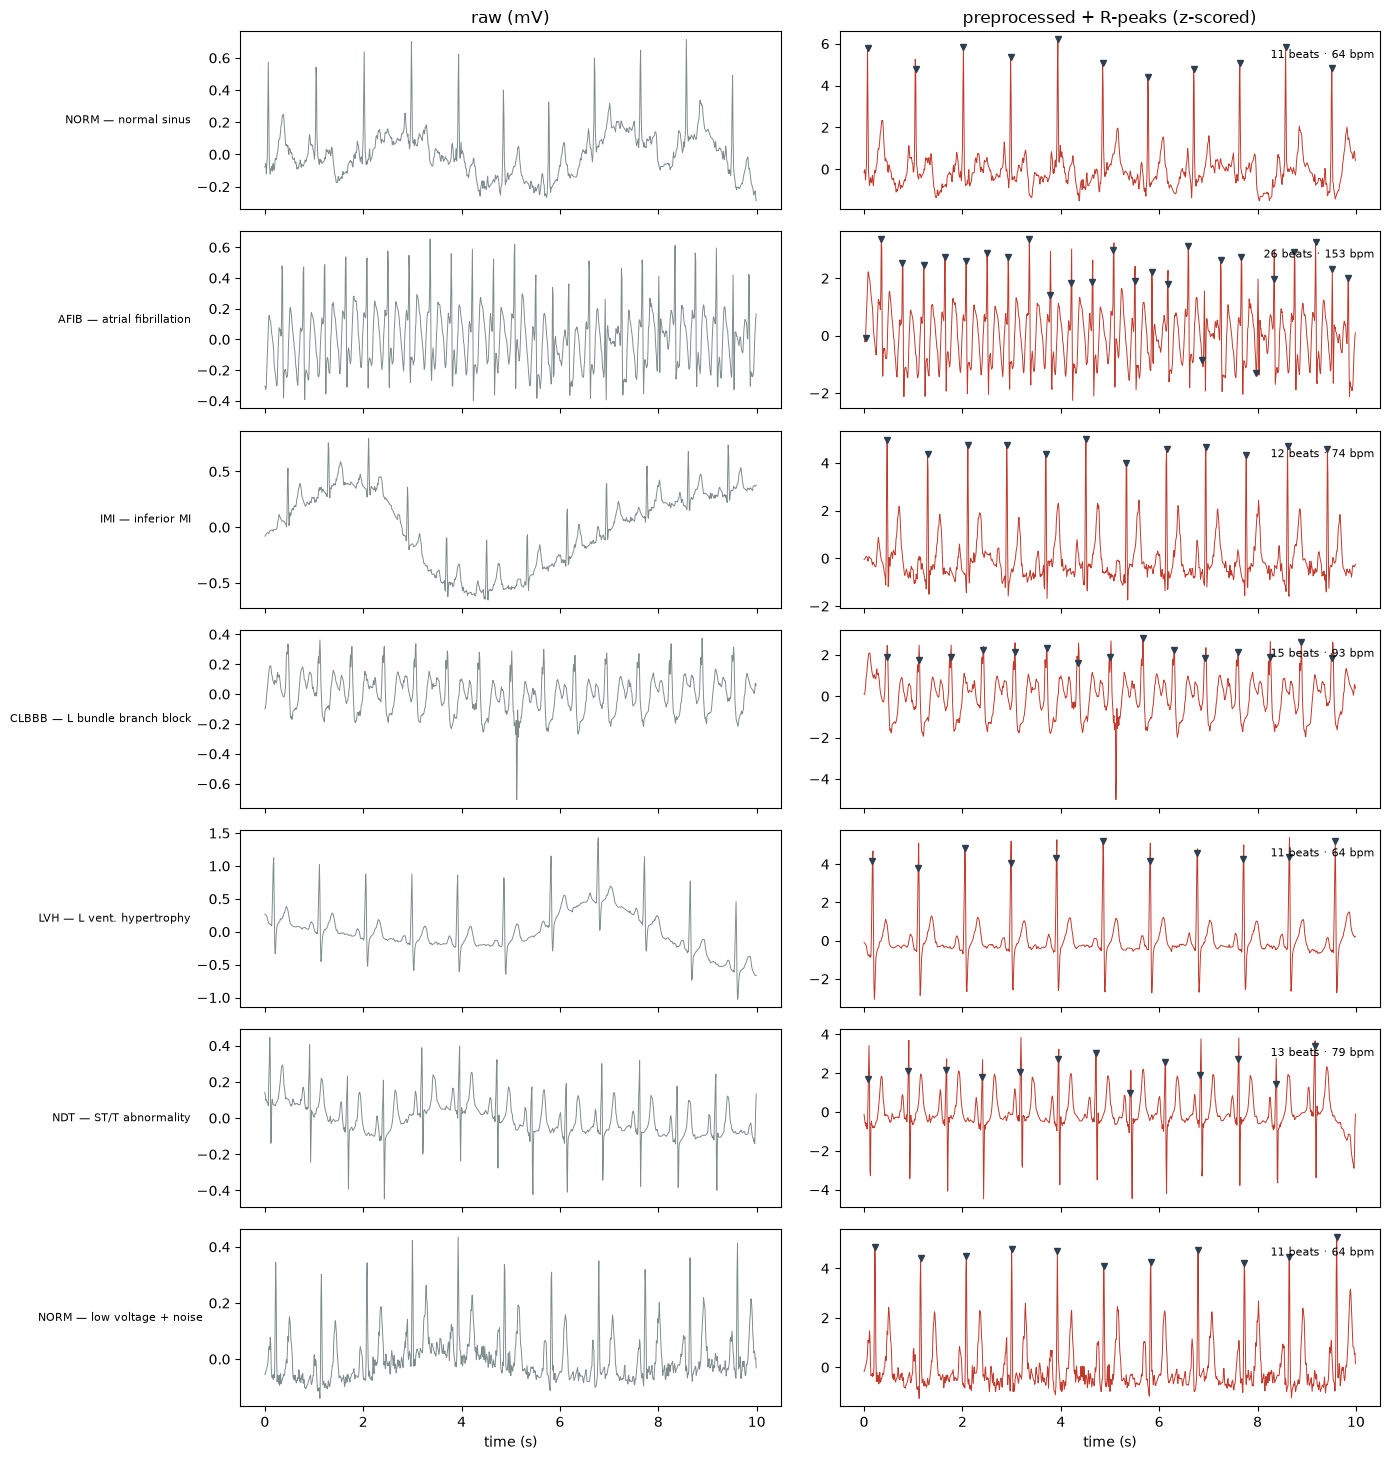

In [2]:
fig, ax = plt.subplots(len(SAMPLES), 2, figsize=(14, 2.1*len(SAMPLES)), sharex=True)
for i,(eid,note) in enumerate(SAMPLES):
    raw, fs = load(eid)
    clean, rpeaks = preprocess(raw, fs_in=fs)
    t = np.arange(clean.shape[-1]) / 100
    ax[i,0].plot(t, raw[1], lw=0.7, color="#7f8c8d")
    ax[i,0].set_ylabel(note, fontsize=8, rotation=0, ha="right", va="center")
    ax[i,1].plot(t, clean[1], lw=0.7, color="#c0392b")
    ax[i,1].plot(rpeaks/100, clean[1][rpeaks], "v", ms=5, color="#2c3e50")
    hr = seg.heart_rate_bpm(rpeaks, 100)
    ax[i,1].text(0.99, 0.85, f"{len(rpeaks)} beats · {hr:.0f} bpm",
                 transform=ax[i,1].transAxes, ha="right", fontsize=8)
ax[0,0].set_title("raw (mV)"); ax[0,1].set_title("preprocessed + R-peaks (z-scored)")
for a in ax[-1]: a.set_xlabel("time (s)")
fig.tight_layout()

## 2. Band-pass removes baseline wander
Record 30 is flagged for baseline drift. The 0.5 Hz high-pass flattens the slow sag.

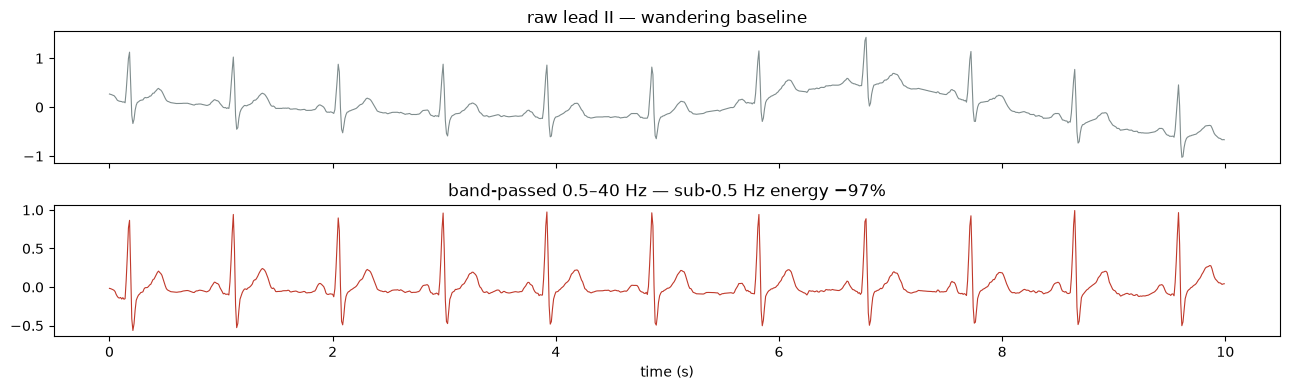

In [3]:
raw, fs = load(30)
bp = bandpass(raw, fs)
t = np.arange(raw.shape[-1]) / fs
lf = lambda x: np.abs(np.fft.rfft(x))[:5].sum()   # <~0.5 Hz energy
red = 100*(1 - lf(bp[1])/lf(raw[1]))
fig, ax = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
ax[0].plot(t, raw[1], color="#7f8c8d", lw=0.8); ax[0].set_title(f"raw lead II — wandering baseline")
ax[1].plot(t, bp[1], color="#c0392b", lw=0.8); ax[1].set_title(f"band-passed 0.5–40 Hz — sub-0.5 Hz energy −{red:.0f}%")
ax[1].set_xlabel("time (s)"); fig.tight_layout()

## 3. Resampling 500 Hz → 100 Hz
Overlay of one beat: polyphase resampling preserves QRS morphology while anti-aliasing.

shapes: (12, 5000) -> (12, 1000)


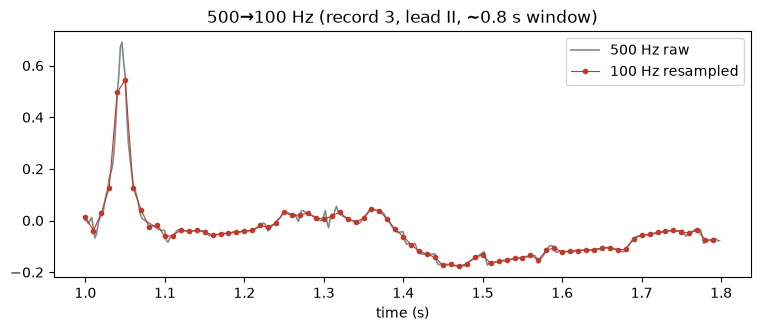

In [4]:
raw5, fs5 = load(3, hr=True)          # 500 Hz
ds = resample_signal(raw5, fs5, 100)  # -> 100 Hz
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(np.arange(500,900)/500, raw5[1,500:900], color="#7f8c8d", lw=1.2, label="500 Hz raw")
ax.plot(np.arange(100,180)/100, ds[1,100:180], "o-", color="#c0392b", ms=3, lw=0.8, label="100 Hz resampled")
ax.set_xlabel("time (s)"); ax.set_title("500→100 Hz (record 3, lead II, ~0.8 s window)"); ax.legend()
print("shapes:", raw5.shape, "->", ds.shape)

## 4. Pan-Tompkins internals
band-pass (5–15 Hz) → derivative → square → moving-window integration → adaptive threshold.

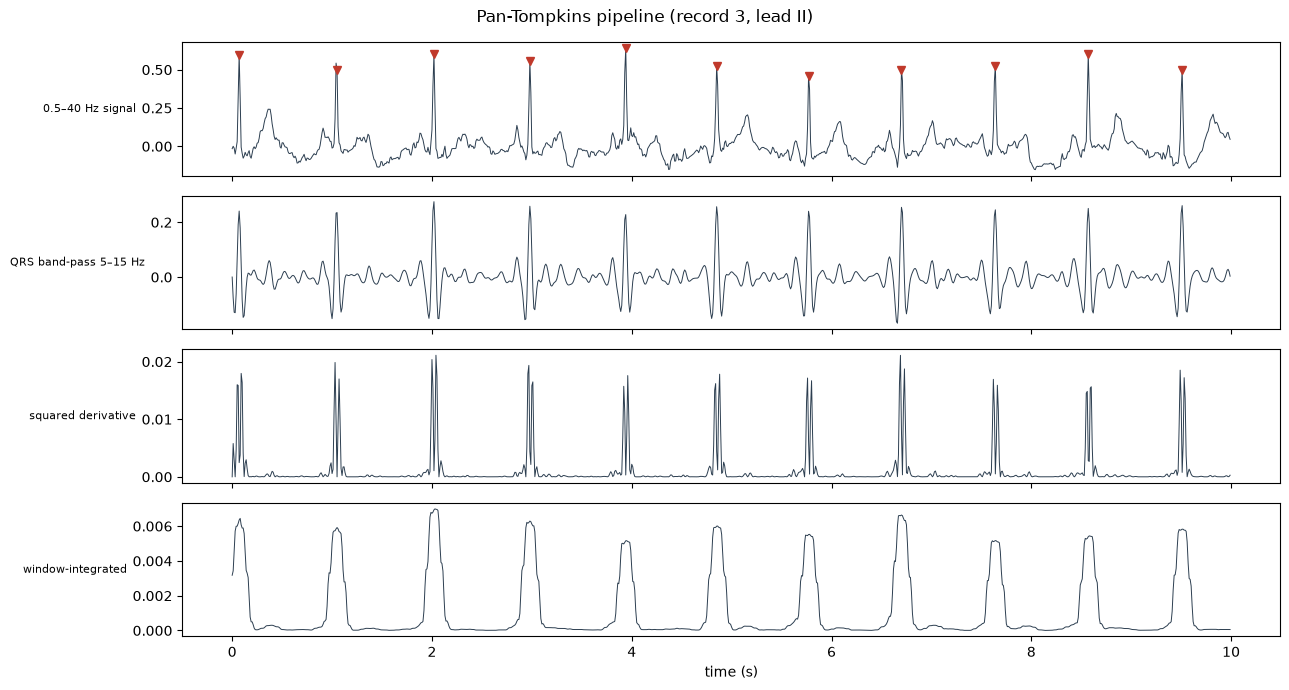

In [5]:
raw, fs = load(3)
filt = filtered_signal(raw, fs)[1]           # 0.5–40 Hz lead II
qrs_bp = seg._qrs_bandpass(filt, 100)
deriv = np.ediff1d(qrs_bp, to_begin=0.0)
squared = deriv**2
win = int(round(0.150*100))
integ = np.convolve(squared, np.ones(win)/win, mode="same")
rpeaks = seg.pan_tompkins_rpeaks(filt, 100)
t = np.arange(len(filt))/100
stages = [("0.5–40 Hz signal", filt), ("QRS band-pass 5–15 Hz", qrs_bp),
          ("squared derivative", squared), ("window-integrated", integ)]
fig, ax = plt.subplots(4, 1, figsize=(13, 7), sharex=True)
for a,(name,s) in zip(ax, stages):
    a.plot(t, s, lw=0.7, color="#2c3e50"); a.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
ax[0].plot(rpeaks/100, filt[rpeaks], "v", color="#c0392b", ms=6)
ax[-1].set_xlabel("time (s)"); fig.suptitle("Pan-Tompkins pipeline (record 3, lead II)"); fig.tight_layout()

## 5. Per-lead z-score normalization
All 12 leads on a common scale (mean 0, unit variance) so no lead dominates the model.

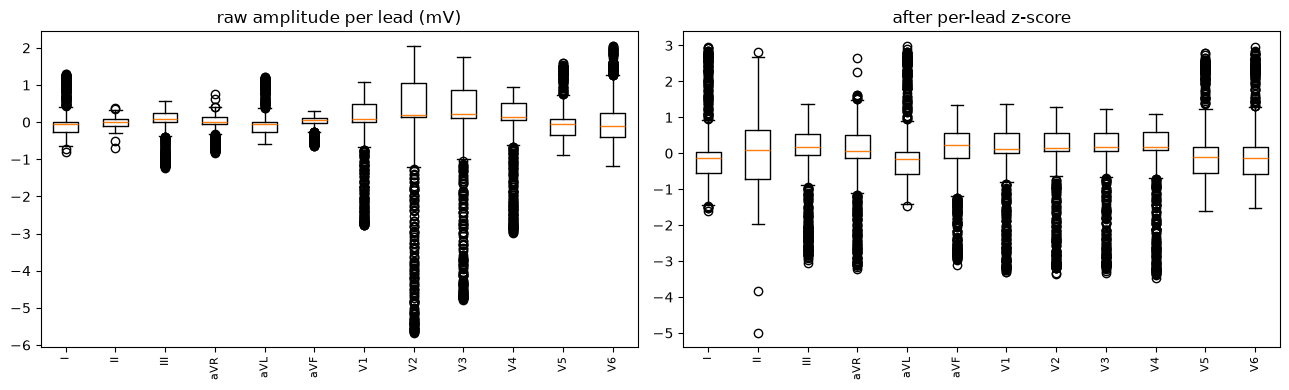

In [6]:
raw, fs = load(180)   # CLBBB — large amplitude differences across leads
clean, _ = preprocess(raw, fs_in=fs)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].boxplot(raw.T, tick_labels=LEADS); ax[0].set_title("raw amplitude per lead (mV)")
ax[1].boxplot(clean.T, tick_labels=LEADS); ax[1].set_title("after per-lead z-score")
for a in ax: a.tick_params(axis="x", labelrotation=90, labelsize=8)
fig.tight_layout()

## 6. Beat segmentation → median beat
R-peak-centred windows (0.25 s pre, 0.45 s post) averaged into a representative beat.

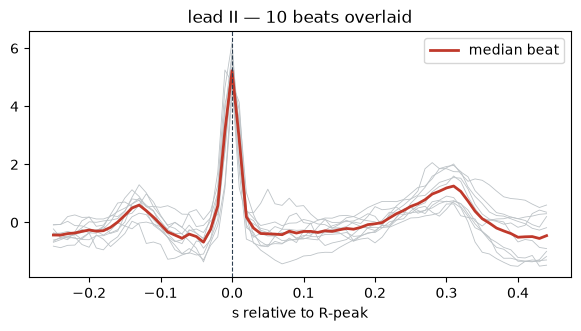

In [7]:
raw, fs = load(3)
clean, rpeaks = preprocess(raw, fs_in=fs)
beats = seg.segment_beats(clean, rpeaks, 100)     # (n_beats, 12, 70)
tw = (np.arange(beats.shape[-1]) - 25)/100         # s relative to R
fig, ax = plt.subplots(figsize=(7, 3.2))
for b in beats[:, 1]: ax.plot(tw, b, color="#bdc3c7", lw=0.6)
ax.plot(tw, beats[:,1].mean(0), color="#c0392b", lw=2, label="median beat")
ax.axvline(0, color="#2c3e50", ls="--", lw=0.8); ax.set_xlabel("s relative to R-peak")
ax.set_title(f"lead II — {beats.shape[0]} beats overlaid"); ax.legend()

## 7. The torch Dataset
`PTBXLDataset` applies this exact chain and yields `(12, 1000)` tensors + `(71,)` labels.

In [8]:
from torch.utils.data import DataLoader
from src.detection.dataset import PTBXLDataset

ds = PTBXLDataset(split="train", ecg_ids=[3, 22, 1])   # sample records that are in train folds
sig, label = ds[0]
print("dataset len:", len(ds))
print("signal:", tuple(sig.shape), sig.dtype, "| label:", tuple(label.shape), "| positives:", int(label.sum()))
xb, yb = next(iter(DataLoader(ds, batch_size=3)))
print("batch:", tuple(xb.shape), tuple(yb.shape))

dataset len: 3
signal: (12, 1000) torch.float32 | label: (71,) | positives: 3
batch: (3, 12, 1000) (3, 71)


## Takeaways
- Band-pass cleanly removes baseline wander (−~97% sub-0.5 Hz energy) and HF noise.
- Pan-Tompkins gives physiologic beat counts/rates across rhythms (sinus ~60–80,
  AFIB faster/irregular); R-peaks feed beat windows and the grounding overlay.
- Per-lead z-score puts all 12 leads on one scale for the detector.
- `PTBXLDataset(transform="default")` bakes the whole chain in → ready for Phase 3.